Dataset Link: https://microdata.statistics.gov.rw/index.php/catalog/82


Github Link: https://github.com/boaziza/formative2-pca-pair-team-34.git

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





In [ ]:
# Setup: only numpy and matplotlib are used in this notebook
import numpy as np
import matplotlib.pyplot as plt
import time  # standard-library timer, used only for benchmarking in Task 3

np.set_printoptions(precision=4, suppress=True, linewidth=120)

# Path to the dataset (CSV exported from NISR EICV5 microdata)
DATA_PATH = "data/eicv5_pca_subset.csv"

print("numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)
print("Data file:", DATA_PATH)


numpy 2.5.3 | matplotlib 3.11.2
Data file: data/eicv5_pca_subset.csv


### Data Handling: load, inspect missing values, impute and encode
Non-numeric columns are encoded and missing values imputed before standardization.

In [ ]:
# Load the raw CSV with numpy only: read every cell as text first,
# then decide column by column which ones are numeric.
raw = np.genfromtxt(DATA_PATH, delimiter=",", dtype=str, encoding="utf-8")
raw = np.char.strip(np.char.strip(raw), '"')   # remove spaces and quote marks

column_names = [str(c) for c in raw[0]]
data_str = raw[1:]
print("Shape (rows, columns):", data_str.shape)
print("Columns:", list(column_names))
data_str[:5]


Shape (rows, columns): (14580, 13)
Columns: ['province', 'urban_rural', 'hh_size', 'consumption_per_ae', 'food_share', 'food_expenditure', 'own_food_production', 'annual_nonfood_exp', 'education_exp', 'water_exp', 'electricity_exp', 'durable_goods_value', 'transfers_received']


array([['Kigali City', 'Urban', '2.0000', '666627.3125', '0.5264', '665029.9989', '19770.8340', '35500.0000',
        '0.0000', '12000.0000', '13000.0000', '2555.5555', '17000.0000'],
       ['Kigali City', 'Urban', '4.0000', '653076.2072', '0.4182', '836336.6638', '0.0000', '40000.0000',
        '33000.0000', '48000.0000', '78000.0000', '16944.4444', '16500.0000'],
       ['Kigali City', 'Urban', '4.0000', '900828.9873', '0.3969', '1160213.3325', '0.0000', '119700.0000', '0.0000',
        '19821.4297', '13000.0000', '14000.0000', '1000.0000'],
       ['Kigali City', 'Urban', '3.0000', '1186645.0990', '0.6319', '1421431.6533', '0.0000', '17500.0000',
        '30000.0000', '1564.2858', '0.0000', '20013.8887', '3000.0000'],
       ['Kigali City', 'Urban', '4.0000', '1099580.5585', '0.2744', '1006791.6680', '0.0000', '83000.0000',
        '453000.0000', '75000.0000', '78000.0000', '105777.7779', '17500.0000']], dtype='<U19')

In [ ]:
# Identify numeric vs non-numeric columns and count missing values
MISSING_TOKENS = {"", "nan", "na", "n/a", "null", ".", "none", "?"}

def is_missing(arr):
    return np.isin(np.char.lower(arr), list(MISSING_TOKENS))

def is_numeric_column(col):
    present = col[~is_missing(col)]
    try:
        present.astype(float)
        return True
    except ValueError:
        return False

numeric_idx = [j for j in range(data_str.shape[1]) if is_numeric_column(data_str[:, j])]
categorical_idx = [j for j in range(data_str.shape[1]) if j not in numeric_idx]

print("Numeric columns:     ", [column_names[j] for j in numeric_idx])
print("Non-numeric columns: ", [column_names[j] for j in categorical_idx])
print()
print(f"{'Column':<25}{'Type':<14}{'Missing':>8}{'% Missing':>11}")
for j, name in enumerate(column_names):
    n_miss = is_missing(data_str[:, j]).sum()
    kind = "numeric" if j in numeric_idx else "categorical"
    print(f"{name:<25}{kind:<14}{n_miss:>8}{100 * n_miss / len(data_str):>10.2f}%")
print("\nTotal missing cells:", is_missing(data_str).sum())


Numeric columns:      ['hh_size', 'consumption_per_ae', 'food_share', 'food_expenditure', 'own_food_production', 'annual_nonfood_exp', 'education_exp', 'water_exp', 'electricity_exp', 'durable_goods_value', 'transfers_received']
Non-numeric columns:  ['province', 'urban_rural']

Column                   Type           Missing  % Missing
province                 categorical          0      0.00%
urban_rural              categorical          0      0.00%
hh_size                  numeric              0      0.00%
consumption_per_ae       numeric              0      0.00%
food_share               numeric              0      0.00%
food_expenditure         numeric              0      0.00%
own_food_production      numeric              0      0.00%
annual_nonfood_exp       numeric              0      0.00%
education_exp            numeric              0      0.00%
water_exp                numeric              0      0.00%
electricity_exp          numeric              0      0.00%
durable_good

In [ ]:
# Impute missing values
#   numeric columns     -> median (robust to the heavy right skew of income/consumption data)
#   categorical columns -> most frequent category (mode)
numeric_data = np.empty((data_str.shape[0], len(numeric_idx)))
for k, j in enumerate(numeric_idx):
    col = data_str[:, j].copy()
    col[is_missing(col)] = "nan"
    numeric_data[:, k] = col.astype(float)

numeric_medians = np.nanmedian(numeric_data, axis=0)
nan_rows, nan_cols = np.where(np.isnan(numeric_data))
numeric_data[nan_rows, nan_cols] = numeric_medians[nan_cols]

categorical_data = data_str[:, categorical_idx].copy()
for k in range(categorical_data.shape[1]):
    col = categorical_data[:, k]
    miss = is_missing(col)
    values, counts = np.unique(col[~miss], return_counts=True)
    mode = values[np.argmax(counts)]
    col[miss] = mode
    print(f"{column_names[categorical_idx[k]]}: filled {miss.sum()} missing with '{mode}'")

for k, j in enumerate(numeric_idx):
    print(f"{column_names[j]}: median used = {numeric_medians[k]:.3f}")

print("\nRemaining NaNs in numeric block:", np.isnan(numeric_data).sum())


province: filled 0 missing with 'Southern'
urban_rural: filled 0 missing with 'Rural'
hh_size: median used = 4.000
consumption_per_ae: median used = 256655.844
food_share: median used = 0.702
food_expenditure: median used = 399153.574
own_food_production: median used = 122501.821
annual_nonfood_exp: median used = 36300.000
education_exp: median used = 4350.000
water_exp: median used = 0.000
electricity_exp: median used = 0.000
durable_goods_value: median used = 1250.000
transfers_received: median used = 16400.000

Remaining NaNs in numeric block: 0


In [ ]:
# Log-transform the money columns: household spending in Rwanda is very right-skewed
# (a few households spend 100x the median), and without this the outliers would
# dominate the covariance matrix. log(1 + x) keeps zero values valid.
MONEY_COLUMNS = ["consumption_per_ae", "food_expenditure", "own_food_production", "annual_nonfood_exp",
                 "education_exp", "water_exp", "electricity_exp", "durable_goods_value", "transfers_received"]
numeric_names = [column_names[j] for j in numeric_idx]
for name in MONEY_COLUMNS:
    if name in numeric_names:
        k = numeric_names.index(name)
        before = numeric_data[:, k].max() / max(np.median(numeric_data[:, k]), 1)
        numeric_data[:, k] = np.log1p(numeric_data[:, k])
        print(f"{name:<22} log1p applied (max was {before:,.0f}x the median)")


consumption_per_ae     log1p applied (max was 120x the median)
food_expenditure       log1p applied (max was 22x the median)
own_food_production    log1p applied (max was 39x the median)
annual_nonfood_exp     log1p applied (max was 444x the median)
education_exp          log1p applied (max was 2,690x the median)
water_exp              log1p applied (max was 1,200,000x the median)
electricity_exp        log1p applied (max was 780,000x the median)
durable_goods_value    log1p applied (max was 51,945x the median)
transfers_received     log1p applied (max was 349x the median)


In [ ]:
# Encode non-numeric columns
#   2 categories         -> single 0/1 column (e.g. Urban/Rural)
#   3 to 10 categories   -> one-hot encoding minus one reference category (e.g. Province);
#                           no false ordering is introduced
#   more than 10         -> frequency encoding (share of households in that category),
#                           which avoids adding dozens of sparse columns (e.g. 30 districts)
encoded_blocks, encoded_names = [], []
for k in range(categorical_data.shape[1]):
    name = column_names[categorical_idx[k]]
    col = categorical_data[:, k]
    categories, codes, counts = np.unique(col, return_inverse=True, return_counts=True)
    if len(categories) == 2:
        encoded_blocks.append(codes.reshape(-1, 1).astype(float))
        encoded_names.append(f"{name}={categories[1]}")
        print(f"{name}: binary (1 = {categories[1]}, 0 = {categories[0]})")
    elif len(categories) <= 10:
        # drop the first category (reference) so the dummies are not perfectly collinear,
        # which would otherwise create a zero eigenvalue
        one_hot = (codes.reshape(-1, 1) == np.arange(1, len(categories))).astype(float)
        encoded_blocks.append(one_hot)
        encoded_names += [f"{name}={c}" for c in categories[1:]]
        print(f"{name}: one-hot -> {len(categories) - 1} columns (reference = {categories[0]})")
    else:
        freq = counts[codes] / len(col)
        encoded_blocks.append(freq.reshape(-1, 1))
        encoded_names.append(f"{name}_freq")
        print(f"{name}: frequency encoded ({len(categories)} categories)")

# Keep a label array for colouring the plots in Step 8 (first categorical column)
group_labels = categorical_data[:, 0] if categorical_data.shape[1] > 0 else None

X = np.hstack([numeric_data] + encoded_blocks)
feature_names = [column_names[j] for j in numeric_idx] + encoded_names
print("\nFinal numeric matrix shape:", X.shape)
print("Features:", feature_names)


province: one-hot -> 4 columns (reference = Eastern)
urban_rural: binary (1 = Urban, 0 = Rural)

Final numeric matrix shape: (14580, 16)
Features: ['hh_size', 'consumption_per_ae', 'food_share', 'food_expenditure', 'own_food_production', 'annual_nonfood_exp', 'education_exp', 'water_exp', 'electricity_exp', 'durable_goods_value', 'transfers_received', 'province=Kigali City', 'province=Northern', 'province=Southern', 'province=Western', 'urban_rural=Urban']


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

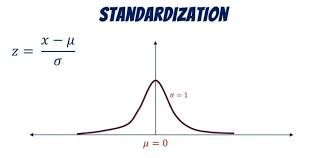


In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
# Z = (X - mean) / standard deviation, computed column by column
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
std[std == 0] = 1.0          # guard against a constant column (division by zero)

standardized_data = (X - mean) / std  # Do not use sklearn

print("Means after standardizing (should be ~0):", standardized_data.mean(axis=0).round(6))
print("Std after standardizing (should be 1):   ", standardized_data.std(axis=0).round(6))
standardized_data[:5]  # Display the first few rows of standardized data


Means after standardizing (should be ~0): [-0.  0. -0. -0. -0.  0. -0. -0.  0.  0.  0.  0.  0. -0. -0. -0.]
Std after standardizing (should be 1):    [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


array([[-1.1383,  1.1382, -0.9442,  0.5075,  0.0434,  0.068 , -1.3204,  1.5017,  1.7056,  0.4031,  0.221 ,  2.8284,
        -0.4439, -0.5979, -0.5472,  2.1845],
       [-0.1941,  1.1113, -1.6809,  0.7207, -2.1047,  0.1462,  0.8563,  1.8202,  2.1315,  0.8815,  0.2096,  2.8284,
        -0.4439, -0.5979, -0.5472,  2.1845],
       [-0.1941,  1.534 , -1.8259,  1.0251, -2.1047,  0.8642, -1.3204,  1.617 ,  1.7056,  0.8332, -0.8629,  2.8284,
        -0.4439, -0.5979, -0.5472,  2.1845],
       [-0.6662,  1.8961, -0.2259,  1.214 , -2.1047, -0.3953,  0.8364,  1.0336, -0.5459,  0.9236, -0.4427,  2.8284,
        -0.4439, -0.5979, -0.5472,  2.1845],
       [-0.1941,  1.796 , -2.6599,  0.8932, -2.1047,  0.6244,  1.4043,  1.9227,  2.1315,  1.3448,  0.2321,  2.8284,
        -0.4439, -0.5979, -0.5472,  2.1845]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
# Cov = (Z^T Z) / (n - 1); Z is already centred, so no extra mean subtraction is needed
n_samples = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n_samples - 1)  # Calculate covariance matrix

# Sanity check against numpy's built-in version
print("Matches np.cov:", np.allclose(cov_matrix, np.cov(standardized_data, rowvar=False)))
print("Shape:", cov_matrix.shape)
cov_matrix


Matches np.cov: True
Shape: (16, 16)


array([[ 1.0001, -0.289 , -0.0031,  0.3035,  0.2531,  0.2981,  0.615 ,  0.0187,  0.0787,  0.2278,  0.0177, -0.0654,
        -0.0093, -0.0075,  0.066 , -0.0355],
       [-0.289 ,  1.0001, -0.5696,  0.4592, -0.327 ,  0.4089, -0.056 ,  0.4121,  0.5199,  0.485 , -0.0156,  0.4449,
        -0.0922, -0.0969, -0.1376,  0.4395],
       [-0.0031, -0.5696,  1.0001, -0.2244,  0.4383, -0.3999, -0.194 , -0.4598, -0.5943, -0.5199,  0.1126, -0.4688,
         0.0987,  0.1109,  0.1239, -0.5403],
       [ 0.3035,  0.4592, -0.2244,  1.0001, -0.1318,  0.4587,  0.2604,  0.2785,  0.3495,  0.3948, -0.0387,  0.2384,
        -0.1419, -0.0238, -0.0451,  0.2559],
       [ 0.2531, -0.327 ,  0.4383, -0.1318,  1.0001, -0.005 ,  0.1756, -0.3168, -0.3671, -0.0909,  0.1465, -0.5054,
         0.1217,  0.0897,  0.0729, -0.5202],
       [ 0.2981,  0.4089, -0.3999,  0.4587, -0.005 ,  1.0001,  0.2976,  0.2534,  0.3203,  0.4818,  0.0061,  0.1644,
         0.0032, -0.087 , -0.0565,  0.178 ],
       [ 0.615 , -0.056 , -0.194 ,

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

**Answer:**
We compute the covariance matrix because (1) it summarises how every pair of features moves together; for example, `consumption_per_ae` and `food_share` have a covariance of -0.57, so richer households spend a smaller share on food, and PCA uses this to group redundant features. (2) Its eigenvectors are the directions of maximum spread in the data and its eigenvalues are the variance along each direction, so PCA is simply the eigendecomposition of this matrix. (3) Because the data is standardized, the covariance matrix equals the correlation matrix, so features measured in RWF and features that are ratios or 0/1 flags all get equal weight.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
# The covariance matrix is symmetric, so eigh is used: it guarantees real eigenvalues
# and orthonormal eigenvectors (np.linalg.eig can return tiny complex parts)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # Perform eigendecomposition

# Check: C v = lambda v for every pair
print("C v = lambda v holds:", np.allclose(cov_matrix @ eigenvectors, eigenvectors * eigenvalues))
eigenvalues, eigenvectors


C v = lambda v holds: True


(array([0.1731, 0.2521, 0.2714, 0.4211, 0.4342, 0.4583, 0.5257, 0.5521, 0.6636, 0.7429, 0.8873, 1.1352, 1.2746, 1.3482,
        2.2365, 4.6249]),
 array([[-0.5295, -0.2136,  0.2386, -0.028 , -0.1589,  0.3526, -0.0033,  0.0394,  0.009 , -0.1202,  0.1792,  0.3098,
          0.1298, -0.0217, -0.5516, -0.0319],
        [-0.6791, -0.1183, -0.0312, -0.0141,  0.1372, -0.3661, -0.1191, -0.0335, -0.0538, -0.0288, -0.1669, -0.4105,
         -0.1182,  0.0731,  0.1197, -0.3489],
        [-0.2183,  0.332 , -0.618 , -0.0991, -0.1343,  0.1   , -0.2257, -0.033 ,  0.0626, -0.4698, -0.0633, -0.0339,
          0.0232, -0.01  , -0.0316,  0.3726],
        [ 0.3552, -0.0789,  0.2387,  0.067 ,  0.1896, -0.0398, -0.1837,  0.2137,  0.0241, -0.6841, -0.1441, -0.213 ,
          0.1009,  0.1117, -0.2569, -0.2566],
        [ 0.1676, -0.1418,  0.1845, -0.359 , -0.3657, -0.2965, -0.361 , -0.3581,  0.0763,  0.1569, -0.1921, -0.1724,
         -0.1423,  0.041 , -0.3572,  0.249 ],
        [ 0.0822,  0.159 , -0.199 , -0.

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly (columns)

print("Sorted eigenvalues:", sorted_eigenvalues)
sorted_eigenvectors


Sorted eigenvalues: [4.6249 2.2365 1.3482 1.2746 1.1352 0.8873 0.7429 0.6636 0.5521 0.5257 0.4583 0.4342 0.4211 0.2714 0.2521 0.1731]


array([[-0.0319, -0.5516, -0.0217,  0.1298,  0.3098,  0.1792, -0.1202,  0.009 ,  0.0394, -0.0033,  0.3526, -0.1589,
        -0.028 ,  0.2386, -0.2136, -0.5295],
       [-0.3489,  0.1197,  0.0731, -0.1182, -0.4105, -0.1669, -0.0288, -0.0538, -0.0335, -0.1191, -0.3661,  0.1372,
        -0.0141, -0.0312, -0.1183, -0.6791],
       [ 0.3726, -0.0316, -0.01  ,  0.0232, -0.0339, -0.0633, -0.4698,  0.0626, -0.033 , -0.2257,  0.1   , -0.1343,
        -0.0991, -0.618 ,  0.332 , -0.2183],
       [-0.2566, -0.2569,  0.1117,  0.1009, -0.213 , -0.1441, -0.6841,  0.0241,  0.2137, -0.1837, -0.0398,  0.1896,
         0.067 ,  0.2387, -0.0789,  0.3552],
       [ 0.249 , -0.3572,  0.041 , -0.1423, -0.1724, -0.1921,  0.1569,  0.0763, -0.3581, -0.361 , -0.2965, -0.3657,
        -0.359 ,  0.1845, -0.1418,  0.1676],
       [-0.2501, -0.326 ,  0.0441, -0.1345, -0.2459, -0.2021, -0.0294, -0.1211, -0.0263,  0.6886,  0.0207, -0.3833,
        -0.0227, -0.199 ,  0.159 ,  0.0822],
       [-0.0977, -0.4966, -0.0071,

### Task 2: Explained Variance and Dynamic Selection of Components
Each eigenvalue is the variance captured by its principal component. Dividing by the sum of all eigenvalues gives the share of total variance explained. The number of components is chosen automatically as the smallest *k* whose cumulative explained variance reaches the threshold below.

In [ ]:
# Task 2: Explained variance ratio and cumulative explained variance
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"{'PC':<6}{'Eigenvalue':>12}{'Explained %':>14}{'Cumulative %':>15}")
for i, (ev, r, c) in enumerate(zip(sorted_eigenvalues, explained_variance_ratio, cumulative_variance), 1):
    print(f"PC{i:<4}{ev:>12.4f}{100 * r:>13.2f}%{100 * c:>14.2f}%")


PC      Eigenvalue   Explained %   Cumulative %
PC1         4.6249        28.90%         28.90%
PC2         2.2365        13.98%         42.88%
PC3         1.3482         8.43%         51.31%
PC4         1.2746         7.97%         59.27%
PC5         1.1352         7.09%         66.37%
PC6         0.8873         5.55%         71.91%
PC7         0.7429         4.64%         76.55%
PC8         0.6636         4.15%         80.70%
PC9         0.5521         3.45%         84.15%
PC10        0.5257         3.29%         87.44%
PC11        0.4583         2.86%         90.30%
PC12        0.4342         2.71%         93.02%
PC13        0.4211         2.63%         95.65%
PC14        0.2714         1.70%         97.34%
PC15        0.2521         1.58%         98.92%
PC16        0.1731         1.08%        100.00%


Components needed for 80% of variance: 8 (retains 80.70%, discards 19.30%)
Kaiser rule (eigenvalue > 1) would keep: 5
Dimensions reduced from 16 to 8


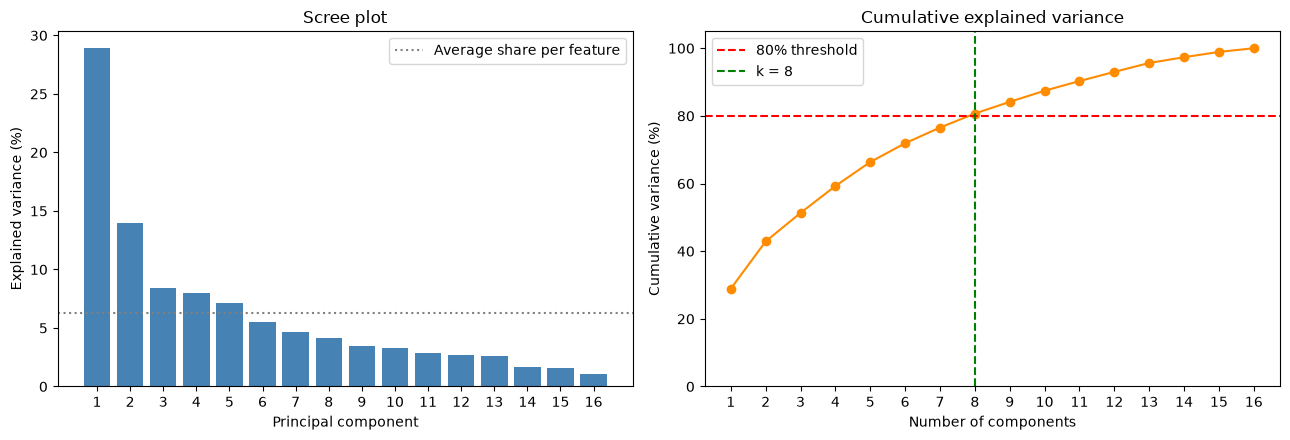

In [ ]:
# Dynamic selection: smallest k whose cumulative explained variance >= threshold
VARIANCE_THRESHOLD = 0.80   # set by the team; justify this choice in the answer below

def select_num_components(eigvals_sorted, threshold):
    cumulative = np.cumsum(eigvals_sorted) / np.sum(eigvals_sorted)
    return int(np.argmax(cumulative >= threshold) + 1)

k_selected = select_num_components(sorted_eigenvalues, VARIANCE_THRESHOLD)
k_kaiser = int(np.sum(sorted_eigenvalues > 1))   # Kaiser rule, shown for comparison only

print(f"Components needed for {VARIANCE_THRESHOLD:.0%} of variance: {k_selected} "
      f"(retains {cumulative_variance[k_selected - 1]:.2%}, discards {1 - cumulative_variance[k_selected - 1]:.2%})")
print(f"Kaiser rule (eigenvalue > 1) would keep: {k_kaiser}")
print(f"Dimensions reduced from {standardized_data.shape[1]} to {k_selected}")

pcs = np.arange(1, len(sorted_eigenvalues) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(pcs, 100 * explained_variance_ratio, color="steelblue")
ax[0].axhline(100 / len(pcs), color="grey", ls=":", label="Average share per feature")
ax[0].set(title="Scree plot", xlabel="Principal component", ylabel="Explained variance (%)", xticks=pcs)
ax[0].legend()
ax[1].plot(pcs, 100 * cumulative_variance, "o-", color="darkorange")
ax[1].axhline(100 * VARIANCE_THRESHOLD, color="red", ls="--", label=f"{VARIANCE_THRESHOLD:.0%} threshold")
ax[1].axvline(k_selected, color="green", ls="--", label=f"k = {k_selected}")
ax[1].set(title="Cumulative explained variance", xlabel="Number of components", ylabel="Cumulative variance (%)", xticks=pcs, ylim=(0, 105))
ax[1].legend()
plt.tight_layout()
plt.show()


In [ ]:
# Loadings: which original features drive each retained component
# (use this table when explaining what each PC represents and what is lost)
print(f"{'Feature':<28}" + "".join(f"{'PC' + str(i + 1):>9}" for i in range(k_selected)))
for f, row in zip(feature_names, sorted_eigenvectors[:, :k_selected]):
    print(f"{f:<28}" + "".join(f"{v:>9.3f}" for v in row))

# How much of each original feature's variance survives in the kept components
retained_per_feature = (sorted_eigenvectors[:, :k_selected] ** 2 * sorted_eigenvalues[:k_selected]).sum(axis=1)
print("\nShare of each feature's variance kept after reduction:")
for f, r in sorted(zip(feature_names, retained_per_feature), key=lambda t: t[1]):
    print(f"  {f:<28}{r:>7.1%}")


Feature                           PC1      PC2      PC3      PC4      PC5      PC6      PC7      PC8
hh_size                        -0.032   -0.552   -0.022    0.130    0.310    0.179   -0.120    0.009
consumption_per_ae             -0.349    0.120    0.073   -0.118   -0.411   -0.167   -0.029   -0.054
food_share                      0.373   -0.032   -0.010    0.023   -0.034   -0.063   -0.470    0.063
food_expenditure               -0.257   -0.257    0.112    0.101   -0.213   -0.144   -0.684    0.024
own_food_production             0.249   -0.357    0.041   -0.142   -0.172   -0.192    0.157    0.076
annual_nonfood_exp             -0.250   -0.326    0.044   -0.135   -0.246   -0.202   -0.029   -0.121
education_exp                  -0.098   -0.497   -0.007    0.076    0.294    0.226    0.136   -0.020
water_exp                      -0.294    0.039   -0.041   -0.075    0.068    0.027    0.001    0.920
electricity_exp                -0.358   -0.001   -0.053    0.020    0.041    0.052    0.174

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = k_selected  # Decide on the number of principal components to keep (chosen in Task 2)
W = sorted_eigenvectors[:, :num_components]          # projection matrix (features x k)
reduced_data = standardized_data @ W  # Project data onto the principal components
reduced_data[:5]


array([[-3.6118,  2.1892, -0.2446, -0.1741, -0.2852,  0.6113, -0.4887,  0.1672],
       [-5.1212,  1.1975, -0.3559,  0.3491,  0.9595,  1.6257, -0.2143,  0.1305],
       [-5.2221,  2.1222, -0.0972,  0.2499,  0.4734,  0.0151, -0.786 , -0.1458],
       [-3.6986,  1.5867, -0.0255,  0.4561,  0.6515,  0.6689, -1.6486, -0.4746],
       [-6.1114,  0.7333, -0.2522,  0.1758,  0.6401,  1.5126,  0.3188, -0.0121]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (14580, 8)


array([[-3.6118,  2.1892, -0.2446, -0.1741, -0.2852,  0.6113, -0.4887,  0.1672],
       [-5.1212,  1.1975, -0.3559,  0.3491,  0.9595,  1.6257, -0.2143,  0.1305],
       [-5.2221,  2.1222, -0.0972,  0.2499,  0.4734,  0.0151, -0.786 , -0.1458],
       [-3.6986,  1.5867, -0.0255,  0.4561,  0.6515,  0.6689, -1.6486, -0.4746],
       [-6.1114,  0.7333, -0.2522,  0.1758,  0.6401,  1.5126,  0.3188, -0.0121]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

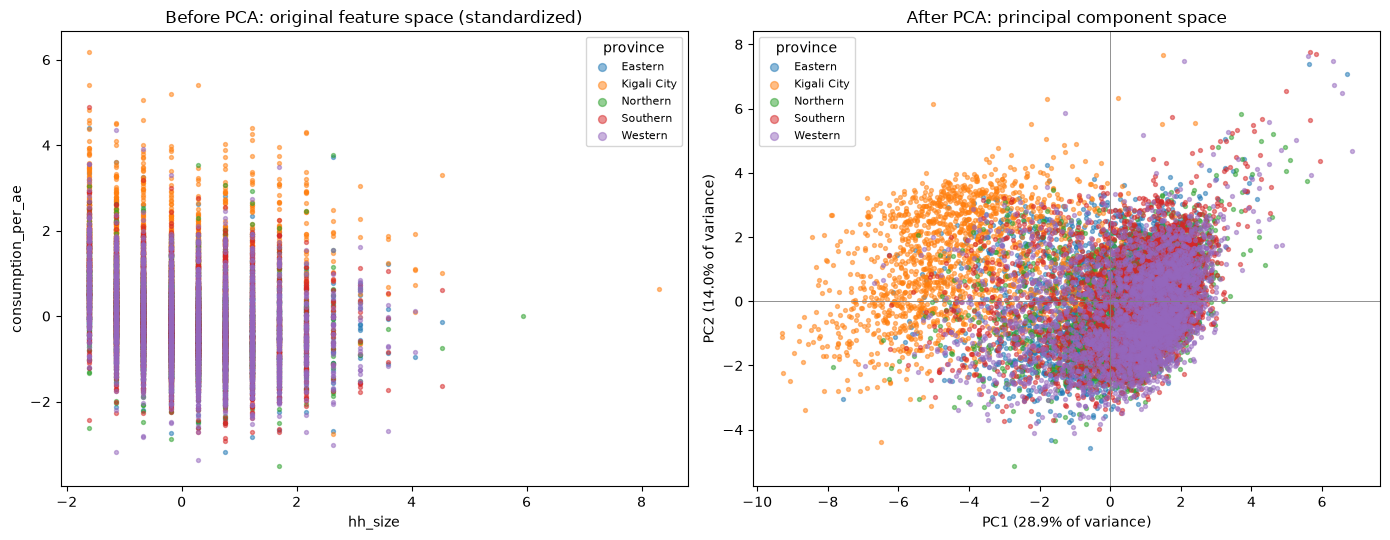

Points before / after: 14580 / 14580
Variance of PC1, PC2: [4.6249 2.2365] (equal to the top two eigenvalues: [4.6249 2.2365] )
Mean of PC scores (centred at 0): [-0. -0.  0. -0. -0. -0.  0. -0.]


In [ ]:
# Step 8: Visualize Before and After PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

def scatter_by_group(ax, x, y):
    if group_labels is None:
        ax.scatter(x, y, s=8, alpha=0.5)
        return
    for g in np.unique(group_labels):
        m = group_labels == g
        ax.scatter(x[m], y[m], s=8, alpha=0.5, label=g)
    ax.legend(title=column_names[categorical_idx[0]], fontsize=8, markerscale=2)

# Plot original data (first two features for simplicity)
scatter_by_group(axes[0], standardized_data[:, 0], standardized_data[:, 1])
axes[0].set(title="Before PCA: original feature space (standardized)",
            xlabel=feature_names[0], ylabel=feature_names[1])

# Plot reduced data after PCA
scatter_by_group(axes[1], reduced_data[:, 0], reduced_data[:, 1])
axes[1].axhline(0, color="grey", lw=0.6); axes[1].axvline(0, color="grey", lw=0.6)
axes[1].set(title="After PCA: principal component space",
            xlabel=f"PC1 ({explained_variance_ratio[0]:.1%} of variance)",
            ylabel=f"PC2 ({explained_variance_ratio[1]:.1%} of variance)")
plt.tight_layout()
plt.show()

print("Points before / after:", standardized_data.shape[0], "/", reduced_data.shape[0])
print("Variance of PC1, PC2:", reduced_data[:, :2].var(axis=0, ddof=1).round(4),
      "(equal to the top two eigenvalues:", sorted_eigenvalues[:2].round(4), ")")
print("Mean of PC scores (centred at 0):", reduced_data.mean(axis=0).round(6))


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

**1. Interpretation of the before/after plots**
In the graph before PCA, the normalized hh_size and consumption_per_ae variables depict overlapping distributions for each province, but with vertical bars due to the discrete nature of household size. In the plot after PCA, PC1 and PC2 are used to depict the observations, and Kigali City generally appears in negative PC1 values.



**2. Why we chose k components and the tradeoffs**

The number of the selected principal components is 8 since this is the minimum amount of them that can be used for capturing at least 80% of variance. In total, 80.70% of the variance is explained by the components while the rest, 19.30%, is ignored. Only PC1 and PC2 are plotted in order to visualize them, although two components explain only 42.88% of variance.



**3. What information is lost when reducing dimensions (for our dataset)**

The reduction in data from 16 variables to eight principal components results in a loss of about 19.30% of the total variation. This is because of small variations and other features that could assist in identifying economic performance and population stress between different houses or provinces. Moreover, the principal components are a combination of variables making them difficult to interpret.



### Task 3: Optimized PCA for Large Datasets
The optimized version: (1) builds the covariance with one matrix product (BLAS) instead of Python loops, (2) uses `eigh` for the symmetric matrix, (3) can use `float32` to halve memory, and (4) can stream the data in chunks, so the full dataset never has to fit in memory at once; only running sums and a small *d × d* matrix are kept.

In [ ]:
# Task 3: baseline (loop-based) vs optimized PCA

def pca_naive(X, k):
    """Straightforward version: standardize, then covariance with explicit Python loops."""
    Z = (X - X.mean(axis=0)) / X.std(axis=0)
    n, d = Z.shape
    C = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            C[i, j] = np.sum(Z[:, i] * Z[:, j]) / (n - 1)
    vals, vecs = np.linalg.eig(C)
    order = np.argsort(vals.real)[::-1]
    vecs = vecs.real[:, order[:k]]
    return Z @ vecs, vals.real[order]

def pca_optimized(X, k, dtype=np.float64):
    """Vectorized version: one matrix product for the covariance, eigh for the symmetric matrix."""
    X = np.asarray(X, dtype=dtype)
    mu, sd = X.mean(axis=0), X.std(axis=0)
    sd[sd == 0] = 1
    Z = (X - mu) / sd
    C = (Z.T @ Z) / (Z.shape[0] - 1)
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    return Z @ vecs[:, order[:k]], vals[order]

def pca_chunked(X, k, chunk_size=100_000):
    """Out-of-core version: one pass to accumulate sums, so memory use is O(d^2), not O(n*d).
    X can be anything that supports row slicing, e.g. np.load(..., mmap_mode='r')."""
    n, d = X.shape
    s, ss = np.zeros(d), np.zeros((d, d))
    for start in range(0, n, chunk_size):
        block = np.asarray(X[start:start + chunk_size], dtype=np.float64)
        s += block.sum(axis=0)
        ss += block.T @ block
    mu = s / n
    cov_raw = (ss - n * np.outer(mu, mu)) / (n - 1)
    sd = np.sqrt(np.diag(cov_raw) * (n - 1) / n)
    sd[sd == 0] = 1
    C = cov_raw / np.outer(sd, sd)   # covariance of the standardized data
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    W = vecs[:, order[:k]]
    out = np.empty((n, k))
    for start in range(0, n, chunk_size):
        block = np.asarray(X[start:start + chunk_size], dtype=np.float64)
        out[start:start + chunk_size] = ((block - mu) / sd) @ W
    return out, vals[order]

print("Defined: pca_naive, pca_optimized, pca_chunked")


Defined: pca_naive, pca_optimized, pca_chunked


In [ ]:
# Correctness: all three versions must agree with Steps 1-6
# (eigenvector signs are arbitrary, so compare absolute values)
r_naive, v_naive = pca_naive(X, num_components)
r_opt, v_opt = pca_optimized(X, num_components)
r_chunk, v_chunk = pca_chunked(X, num_components, chunk_size=500)

print("Naive eigenvalues match:    ", np.allclose(v_naive, sorted_eigenvalues))
print("Optimized eigenvalues match:", np.allclose(v_opt, sorted_eigenvalues))
print("Chunked eigenvalues match:  ", np.allclose(v_chunk, sorted_eigenvalues))
print("Projections match (naive, optimized, chunked):",
      np.allclose(np.abs(r_naive), np.abs(reduced_data)),
      np.allclose(np.abs(r_opt), np.abs(reduced_data)),
      np.allclose(np.abs(r_chunk), np.abs(reduced_data)))


Naive eigenvalues match:     True
Optimized eigenvalues match: True
Chunked eigenvalues match:   True
Projections match (naive, optimized, chunked): True True True


      Rows   Naive (s)  Optimized f64  Optimized f32   Chunked  Speed-up
    10,000      0.0066         0.0022         0.0012    0.0015      3.0x
    14,580      0.0129         0.0029         0.0018    0.0023      4.4x
    50,000      0.0452         0.0100         0.0072    0.0076      4.5x
   200,000      0.3241         0.0418         0.0284    0.0302      7.8x
 1,000,000     skipped         0.2000         0.1359    0.1277         -


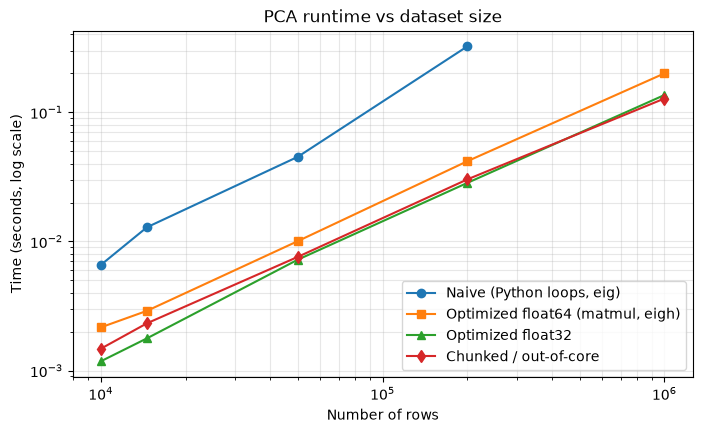

In [ ]:
# Benchmark on larger versions of our dataset (rows resampled with small noise)
def time_it(fn, *args, repeats=3, **kw):
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn(*args, **kw)
        best = min(best, time.perf_counter() - t0)
    return best

rng = np.random.default_rng(42)
sizes = sorted([len(X), 10_000, 50_000, 200_000, 1_000_000])
results = []
for n in sizes:
    X_big = X[rng.integers(0, len(X), n)] + rng.normal(0, 1e-3, (n, X.shape[1]))
    t_naive = time_it(pca_naive, X_big, num_components, repeats=1) if n <= 200_000 else np.nan
    t_opt64 = time_it(pca_optimized, X_big, num_components)
    t_opt32 = time_it(pca_optimized, X_big, num_components, dtype=np.float32)
    t_chunk = time_it(pca_chunked, X_big, num_components, repeats=1)
    results.append((n, t_naive, t_opt64, t_opt32, t_chunk))
    del X_big

print(f"{'Rows':>10}{'Naive (s)':>12}{'Optimized f64':>15}{'Optimized f32':>15}{'Chunked':>10}{'Speed-up':>10}")
for n, a, b, c, d in results:
    speed = f"{a / b:>9.1f}x" if not np.isnan(a) else f"{'-':>10}"
    a_txt = f"{a:>12.4f}" if not np.isnan(a) else f"{'skipped':>12}"
    print(f"{n:>10,}{a_txt}{b:>15.4f}{c:>15.4f}{d:>10.4f}{speed}")

res = np.array(results, dtype=float)
plt.figure(figsize=(8, 4.5))
plt.plot(res[:, 0], res[:, 1], "o-", label="Naive (Python loops, eig)")
plt.plot(res[:, 0], res[:, 2], "s-", label="Optimized float64 (matmul, eigh)")
plt.plot(res[:, 0], res[:, 3], "^-", label="Optimized float32")
plt.plot(res[:, 0], res[:, 4], "d-", label="Chunked / out-of-core")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Number of rows"); plt.ylabel("Time (seconds, log scale)")
plt.title("PCA runtime vs dataset size")
plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.show()
